# <div style="padding:20px;color:white;margin:0;font-size:35px;font-family:Verdana;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>Libraries used</b></div>

In [80]:
#import required packages
import os
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import warnings

#ignoring warnings
warnings.filterwarnings('ignore')

#set base styles for visulizations
sns.set_palette('muted')
sns.set(color_codes = True)
sns.set_style('dark')
sns.despine(left = True)

<Figure size 640x480 with 0 Axes>

<a id="1"></a>
# <div style="padding:20px;color:white;margin:0;font-size:35px;font-family:Verdana;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>A. Introduction (Context and Data Sources)</b></div>

<a id="1.1.1"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #0A800B; background-color: #ffffff;"><b>1. Context </b></h2>

<div style="border-radius:10px;border:#0C6A86 solid;padding: 14px;font-size:100%;text-align:left">
    
We are consulting for an airline company looking to enter the United States domestic market which has identified medium and large airports as their desired operating locations. The company believes that it has a competitive advantage in maintaining punctuality, so it plans on making this a big part of its brand image with a motto, “On time, for you.” 
To kick start operations, the company has decided to start with 5 round trip routes.

Our goal is to analyze Q1-2019 data to provide insights on the items noted below to help support our recommendations on the flight routes. 
Along with our recommendation, we will point out any limitations, risks, and next steps for the company to consider while evaluating the solutions.

Tasks to Perform: 

1. The 10 busiest round trip routes in terms of number of round trip flights in the quarter.
Exclude canceled flights when performing the calculation.
2. The 10 most profitable round trip routes (without considering the upfront airplane cost) in
the quarter. Along with the profit, show total revenue, total cost, summary values of other
key components and total round trip flights in the quarter for the top 10 most profitable
routes. Exclude canceled flights from these calculations.
3. The 5 round trip routes that we recommend to invest in based on any factors.
4. The number of round trip flights it will take to breakeven on the upfront airplane cost for
each of the 5 round trip routes that you recommend. Print key summary components for
these routes.
5. Key Performance Indicators (KPI’s) that we recommend tracking in the future to
measure the success of the round trip routes that you recommend.

<a id="1.1.1"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #0A800B; background-color: #ffffff;"><b>2. Data </b></h2>

<div style="border-radius:10px;border:#0C6A86 solid;padding: 14px; font-size:100%;text-align:left">
    
We have been provided three datasets to perform our analysis on.

1. Flights dataset: Contains data about available routes from origin to destination. For
occupancy, use the data provided in this dataset.
2. Tickets dataset: Ticket prices data (randomly sampled data only as the original dataset
data is huge). Consider only round trips in the analysis.
3. Airport Codes dataset: Identifies whether an airport is considered medium or large
sized. Consider only medium and large airports in the analysis.

<div style="padding: 14px;font-size:100%;text-align:left">
Flights Data Structure:

|Item | Field Name | Description |
|:---| :--- |:--- |
| 1 | FL_DATE | Flight Date (yyyy-mm-dd) |
| 2 | OP_CARRIER | Operating commercial carrier Flight code |
| 3 | TAIL_NUM | Tail Number is the aircraft registration number for the aircraft used (similar to VIN number for cars). |
| 4 | OP_CARRIER_FL_NUM	| Operating commercial carrier Flight number |
| 5 | ORIGIN_AIRPORT_ID	| Origin Airport, Airport ID. An identification number assigned by US DOT to identify a unique airport.  |
| 6 | ORIGIN	| Origin Airport, International Air Transport Association (IATA) Airport Code |
| 7 | ORIGIN_CITY_NAME |	Origin Airport, City Name   |
| 8 | DEST_AIRPORT_ID |	Destination Airport, Airport ID. An identification number assigned by US DOT to identify a unique airport. |
| 9 | DESTINATION |	Destination Airport, Operating commercial carrier Flight code (IATA )Airport Code |
| 10 | DEST_CITY_NAME |	Destination Airport, City Name |
| 11 | DEP_DELAY |	Difference in minutes between scheduled and actual departure time. Early departures show negative numbers. |
| 12 | ARR_DELAY |	Difference in minutes between scheduled and actual arrival time. Early arrivals show negative numbers. |
| 13 | CANCELLED |	Cancelled Flight Indicator (1=Flight is cancelled).  Cancelled flights should be excluded|
| 14 | AIR_TIME |	Flight Time, in Minutes  |
| 15 | DISTANCE |	Distance between Origin and Destination Airports in Miles|
| 16 | OCCUPANCY_RATE |	Occupancy rate of the flight |

<div style="padding: 14px;font-size:100%;text-align:left">
Tickets Data Structure:

|Item | Field Name | Description |
|:---| :--- |:--- |
| 1 | ITIN_ID	| Unique identifier for the itinerary |
| 2 | YEAR	| Year of the Itinerary |
| 3 | QUARTER |	Quarter Number (1-4) for the Itinerary |
| 4| ORIGIN |	Origin Airport Code, International Air Transport Association Airport Code (IATA) which is unique for each airport |
| 5 | ORIGIN_COUNTRY |	Country of the Origin Airport |
| 6 | ORIGIN_STATE_ABR |	Origin Airport, State abbrevations.  |
| 7 | ORIGIN_STATE_NM |	Origin Airport, State Full Name |
| 8 | ROUNDTRIP |	Round Trip Indicator (1= Round Trip and 0 = One Way).  Consider only round trips for your analysis.|
| 9 | REPORTING_CARRIER |	2 character Reporting Airline Carrier codes |
| 10 | PASSENGERS |	Number of Passengers on the itinerary |
| 11 | ITIN_FARE |	Itinerary Fare Per Person. Itinerary fare represents the whole round trip fare if ROUNDTRIP = 1. If ROUNDTRIP = 0, then the itinerary fare represents the one-way ticket fare.|
| 12 | DESTINATION |	Destination Airport Code, International Air Transport Association Airport Code (IATA) which is unique for each airport |

<div style="padding: 14px;font-size:100%;text-align:left">
Airport Codes Data Structure:

|Item | Field Name | Description |
|:---| :--- |:--- |
| 1 | TYPE | The type of the airport, valid value like: small_airport, medium_airport, heliport, etc.|
| 2 | NAME |The name of the airport |
| 3 | ELEVATION_FT | Elevation of the airport from the sea level |
| 4 | CONTINENT | The continent airport belongs to |
| 5 | ISO_COUNTRY | The country of the airports |
| 6 | MUNICIPALITY | The city or town of the airport |
| 7 | IATA_CODE | An airport code is a three-letter geocode designating many airports and metropolitan areas around the world, defined by the International Air Transport Association (IATA). |
| 8 | COORDINATES | Longitude and latitude coordinates of the airporty |


<a id="1.1.1"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #0A800B; background-color: #ffffff;"><b>3. Underlying Assumptions </b></h2>

<div style="border-radius:10px;border:#0C6A86 solid;padding: 14px; font-size:100%;text-align:left">

   
1. Each airplane is dedicated to one round trip route between the 2 airports

2. Costs:
- Fuel, Oil, Maintenance, Crew - $8 per mile total
-  Depreciation, Insurance, Other - $1.18 per mile total
-  Airport operational costs for the right to use the airports and related services arefixed at $5,000 for medium airports and $10,000 for large airports. There is one charge for each airport where a flight lands. Thus, a round trip flight has a total of two airport charges.
-  Delays that are 15 minutes or less are free, however each additional minute of delay costs the airline $75 in added operational costs. This is charged separately for both arrival and departure delays.
-  Each airplane will cost $90 million

3. Revenue:
-  Each plane can accommodate up to 200 passengers and each flight has an associated occupancy rate provided in the Flights data set. Do not use the Tickets data set to determine occupancy.
-  Baggage fee is $35 for each checked bag per flight. We expect 50% of passengers to check an average of 1 bag per flight. The fee is charged separately for each leg of a round trip flight, thus 50% of passengers will be charged a total of $70 in baggage fees for a round trip flight.
-  Disregard seasonal effects on ticket prices (i.e. ticket prices are the same in April as they are on Memorial Day or in December)

<a id="2"></a>
# <div style="padding:20px;color:white;margin:0;font-size:35px;font-family:Verdana;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>B. Data Discovery</b></div>

<a id="1.1.1"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #0A800B; background-color: #ffffff;"><b>1. Import our Data </b></h2>

In [81]:
#Change and set directory to data folders. You can change folder path here if directory changes for the datasets
os.chdir('/workspaces/codespaces-jupyter/C1 DA Challenge')
data_dir = os.getcwd()

Let's read in our datasets and briefly examine the rows to see if there's any issues or anything abnormal after reading in our data.

In [82]:
#Create dataframe for airport codes and check a few rows
airports = pd.read_csv(data_dir + '/Airport_Codes.csv')
airports.sample(5)

,TYPE,NAME,ELEVATION_FT,CONTINENT,ISO_COUNTRY,MUNICIPALITY,IATA_CODE,COORDINATES
4388,small_airport,Westport Airport,80.0,NaN,US,Westport,NaN,"-71.0353012084961, 41.5432014465332"
41650,small_airport,Malloco Airport,935.0,SA,CL,Villarrica,NaN,"-72.34333038330078, -39.25583267211914"
29765,heliport,Boramae Hyundai Apartments Heliport,NaN,AS,KR,Seoul,NaN,"126.923529, 37.492405"
51294,medium_airport,Lokpriya Gopinath Bordoloi International Airport,162.0,AS,IN,Guwahati,GAU,"91.58589935302734, 26.10610008239746"
30584,small_airport,Chubarovka Airport,1100.0,AS,KZ,Chubarovka,NaN,"69.3644027709961, 42.57350158691406"


In [83]:
#Create dataframe for flights and check a few rows
flights = pd.read_csv(data_dir + '/Flights.csv')
flights.sample(5)


,FL_DATE,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DESTINATION,DEST_CITY_NAME,DEP_DELAY,ARR_DELAY,CANCELLED,AIR_TIME,DISTANCE,OCCUPANCY_RATE
920411,2019-02-03,AA,N906NN,2252,11540,ELP,"El Paso, TX",11298,DFW,"Dallas/Fort Worth, TX",-2.0,8.0,0.0,74.0,551.0,0.45
374511,2019-03-01,YV,N954LR,5861,12448,JAN,"Jackson/Vicksburg, MS",11298,DFW,"Dallas/Fort Worth, TX",8.0,14.0,0.0,76.0,408.0,0.31
471988,2019-03-10,WN,N435WN,5432,13198,MCI,"Kansas City, MO",14492,RDU,"Raleigh/Durham, NC",14.0,-10.0,0.0,101.0,904.0,0.78
1367642,2019-01-11,DL,N961DL,1524,10397,ATL,"Atlanta, GA",13851,OKC,"Oklahoma City, OK",-1.0,-13.0,0.0,115.0,761.0,0.88
99327,2019-03-25,AA,N560UW,1929,14057,PDX,"Portland, OR",11057,CLT,"Charlotte, NC",-4.0,10.0,0.0,282.0,2282.0,0.93


In [84]:
#Create dataframe for tickets and check a few rows
tickets = pd.read_csv(data_dir + '/Tickets.csv')
tickets.sample(5)

,ITIN_ID,YEAR,QUARTER,ORIGIN,ORIGIN_COUNTRY,ORIGIN_STATE_ABR,ORIGIN_STATE_NM,ROUNDTRIP,REPORTING_CARRIER,PASSENGERS,ITIN_FARE,DESTINATION
570168,201913917717,2019,1,LIH,US,HI,Hawaii,0.0,UA,2.0,867.0,LAX
412289,201911882095,2019,1,GSP,US,SC,South Carolina,1.0,DL,1.0,409.0,LAX
727521,201915219808,2019,1,ORD,US,IL,Illinois,1.0,YX,1.0,0.0,ABQ
865292,201914848285,2019,1,SAN,US,CA,California,1.0,WN,7.0,207.0,DEN
807461,201915233622,2019,1,PIT,US,PA,Pennsylvania,1.0,YX,1.0,795.0,LGA


<div style="border-radius:5px;border:#696B61 solid;padding: 14px; font-size:100%;text-align:left">

**Takeaway**: All of our data has been imported correctly and we don't see anything abnormal from a quick first glance. We see some columns with missing values in our airports dataset, but we'll explore that further for all of our data.

<a id="1.1.1"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #0A800B; background-color: #ffffff;"><b>2. Subsetting Data and Data Quality </b></h2>

<div style="border-radius:10px;border:#0C6A86 solid;padding: 14px; font-size:100%;text-align:left">

We know there's some preliminary exclusions that we have to consider when working with our data. Let's take a look at the guidelines we've been given.

1. Airports: The airline company is only focused on medium and large airports. We're also interested in the US domestic market, so we can filter out the country to be US only
2. Tickets: Our analysis should be focused on roundtrips only
3. Flights: We should be excluding any cancelled flights from our analysis

Given this information, we can subset our data to meet these conditions.

In [85]:
#Subset our data with the conditiongs outlined above
airports_med_large = airports.query('TYPE == "medium_airport" | TYPE == "large_airport"')
tickets_round_trip = tickets.query('ROUNDTRIP == 1.0')
flights_no_cancellations = flights.query('CANCELLED != 1.0')

#Subset for US airports only
airports_us_med_large = airports_med_large.query('ISO_COUNTRY == "US"')

Now that we've subset our data accordingly, we can explore the data further and perform a few data quality checks. Since we're performing the same checks across 3 different datasets, let's create a few functions to make this process repeatable and efficient. This could be helpful if we're given more data in the future and we can scale the process with minimal changes.

In [86]:
#This function will give us a brief summary of our data and quickly allow us to examine the same variables for all 3 datasets
#We create individual dataframes of the variables we're interested in and then return one dataframe with all of the variables
def summary(df):
    missing_rows = pd.DataFrame({'Missing rows':df.isna().sum()})
    percent_missing_rows = pd.DataFrame({'Percent Missing Rows':(df.isna().sum()/len(df)).mul(100).round(2).astype(str) + '%'})
    dtype = pd.DataFrame({'Data Type':df.dtypes})
    min = pd.DataFrame({'Min Value':df.min()})
    max = pd.DataFrame({'Max Value':df.max()})
    n_unique = pd.DataFrame({'Number of Unique Values':df.nunique()})

    #concat all varibales into one dataframe
    summary_df = pd.concat([missing_rows, percent_missing_rows, dtype,min,max, n_unique], axis =1)
    return summary_df

In [87]:
#Function to output the shape of our data (rows and columns)
def data_shape(df):
    n_rows, n_cols = df.shape
    print(f'Number of rows: {n_rows}')
    print(f'Number of columns: {n_cols}')

In [88]:
#Check for dupliacte rows
def check_duplicates(df, col):
    duplicates = df[df.duplicated(keep= False)]
    duplicates.sort_values(col, inplace= True)
    return duplicates

<a id="1.1.1"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #0A800B; background-color: #ffffff;"><b>I. Airports Data </b></h2>

In [89]:
#Pass the subset airports data through both functions
data_shape(airports_us_med_large)
print('\n-------')
summary(airports_us_med_large)

Number of rows: 858
Number of columns: 8

-------


,Missing rows,Percent Missing Rows,Data Type,Min Value,Max Value,Number of Unique Values
TYPE,0,0.0%,object,large_airport,medium_airport,2
NAME,0,0.0%,object,34S Airport,atl,857
ELEVATION_FT,3,0.35%,float64,-115.0,7820.0,651
CONTINENT,858,100.0%,object,None,None,0
ISO_COUNTRY,0,0.0%,object,US,US,1
MUNICIPALITY,3,0.35%,object,NaN,NaN,716
IATA_CODE,37,4.31%,object,NaN,NaN,821
COORDINATES,0,0.0%,object,"-100.2860031, 44.38270187","174.1139984, 52.71229935",858


<div style="border-radius:5px;border:#696B61 solid;padding: 14px; font-size:100%;text-align:left">

**Takeaway**: 
1. After subsetting the airports data for medium/large US airports, we've narrowed down the airports we'll be interested in analyzing. 
We know the subset was successful because we see only two unique values for our type and one value for the country.
2. We could drop the continent column since all of the values are null if we choose to. 
There is no benefit or drawback to having this column in our data so we'll leave it for now.
3. There are less unique values for municipality when compared to our number of rows indicating there's more than one airport per municipality for certain municipalities. 
This is something to consider if there's competing airports within a region when recommending routes.
4. Overall, there isn't too much concern over the missing values. We will likely need the IATA code to join to the other datasets so we will consider dropping those rows before we begin our analysis. With <5% of data missing, and the correct data types for our columns, we will move on for now.

<a id="1.1.1"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #0A800B; background-color: #ffffff;"><b>II. Tickets Data </b></h2>

In [90]:
#Pass the subset tickets data through both functions
data_shape(tickets_round_trip)
print('\n-------')
summary(tickets_round_trip)

Number of rows: 708600
Number of columns: 12

-------


,Missing rows,Percent Missing Rows,Data Type,Min Value,Max Value,Number of Unique Values
ITIN_ID,0,0.0%,int64,2019119,201915258097,660878
YEAR,0,0.0%,int64,2019,2019,1
QUARTER,0,0.0%,int64,1,1,1
ORIGIN,0,0.0%,object,ABE,YUM,409
ORIGIN_COUNTRY,0,0.0%,object,US,US,1
ORIGIN_STATE_ABR,0,0.0%,object,AK,WY,52
ORIGIN_STATE_NM,0,0.0%,object,Alabama,Wyoming,52
ROUNDTRIP,0,0.0%,float64,1.0,1.0,1
REPORTING_CARRIER,0,0.0%,object,9E,YX,21
PASSENGERS,1197,0.17%,float64,1.0,681.0,223


<div style="border-radius:5px;border:#696B61 solid;padding: 14px; font-size:100%;text-align:left">

**Takeaway**: 
1. We see our subset for roundtrip worked since we see one unique value for the roundtrip column. We could choose to drop this along with year, quarter, and origin country since they all have one unique value.
2. Based on the origin and destination values, we can assume that we have more airports in our airports dataset that we don't have any ticket information on, further narrowing down the airports we might be interested in.
3. The ITIN_ID column is our unique identifier, but we have less unique values when compared to our rows. This suggests that some ID's are repeated. We should perform a check to see if we have duplicate rows.
4. With less than .1% of values missing for passengers, and itin_fare, we could exclude this from our analysis. But before we do that, we should look at to see how these values are distributed to see if a specific airport has a majority of the missing values. The data type for our fare is also an object, we should change this to a numeric value since we need to perform aggregations later on.


In [91]:
#Let's pick a few IDs with more than one count and see what those rows look like
print(tickets_round_trip.value_counts('ITIN_ID'))
check_ids = [201912830259, 201912783574, 201913150921]
tickets_round_trip[tickets_round_trip['ITIN_ID'].isin(check_ids)].sort_values('ITIN_ID')

ITIN_ID
201912830259    4
201912783574    4
201913150921    4
201912922200    4
201911160836    4
               ..
201912020021    1
201912020026    1
201912020029    1
201912020036    1
201915258097    1
Length: 660878, dtype: int64


,ITIN_ID,YEAR,QUARTER,ORIGIN,ORIGIN_COUNTRY,ORIGIN_STATE_ABR,ORIGIN_STATE_NM,ROUNDTRIP,REPORTING_CARRIER,PASSENGERS,ITIN_FARE,DESTINATION
27371,201912783574,2019,1,LAW,US,OK,Oklahoma,1.0,MQ,1.0,707.0,RIC
27522,201912783574,2019,1,LAW,US,OK,Oklahoma,1.0,MQ,1.0,707.0,RIC
1142443,201912783574,2019,1,LAW,US,OK,Oklahoma,1.0,MQ,1.0,707.0,RIC
1142594,201912783574,2019,1,LAW,US,OK,Oklahoma,1.0,MQ,1.0,707.0,RIC
44185,201912830259,2019,1,SJT,US,TX,Texas,1.0,MQ,1.0,1392.0,HSV
44298,201912830259,2019,1,SJT,US,TX,Texas,1.0,MQ,1.0,1392.0,JAN
1159257,201912830259,2019,1,SJT,US,TX,Texas,1.0,MQ,1.0,1392.0,HSV
1159370,201912830259,2019,1,SJT,US,TX,Texas,1.0,MQ,1.0,1392.0,JAN
9835,201913150921,2019,1,CIU,US,MI,Michigan,1.0,OO,1.0,1548.0,LAS
9907,201913150921,2019,1,CIU,US,MI,Michigan,1.0,OO,1.0,1548.0,LAS


From a quick glance, we see there are some rows and IDs that are repeated. Let's see how many of these duplicates we have.

In [92]:
#Use duplicates function to check
check_duplicates(tickets_round_trip, 'ITIN_ID')

,ITIN_ID,YEAR,QUARTER,ORIGIN,ORIGIN_COUNTRY,ORIGIN_STATE_ABR,ORIGIN_STATE_NM,ROUNDTRIP,REPORTING_CARRIER,PASSENGERS,ITIN_FARE,DESTINATION
1036403,20191206,2019,1,ABE,US,PA,Pennsylvania,1.0,9E,1.0,349.0,HOU
52576,20191206,2019,1,ABE,US,PA,Pennsylvania,1.0,9E,1.0,349.0,HOU
1036366,20191377,2019,1,ABE,US,PA,Pennsylvania,1.0,9E,1.0,548.0,SLC
53013,20191377,2019,1,ABE,US,PA,Pennsylvania,1.0,9E,1.0,548.0,SLC
58566,20191463,2019,1,AEX,US,LA,Louisiana,1.0,9E,1.0,306.0,ATL
...,...,...,...,...,...,...,...,...,...,...,...,...
1114770,201915257275,2019,1,VPS,US,FL,Florida,1.0,YX,1.0,314.0,PHL
1114971,201915257577,2019,1,XNA,US,AR,Arkansas,1.0,YX,1.0,386.0,MCO
1034713,201915257577,2019,1,XNA,US,AR,Arkansas,1.0,YX,1.0,386.0,MCO
1034733,201915257772,2019,1,XNA,US,AR,Arkansas,1.0,YX,1.0,531.0,LGA


Based on this, we can approximate ~40K rows are duplicates. Let's drop these duplicated rows from our tickets dataset since we have confirmed that some rows are repeated. 

In [93]:
#Keep the first occurence of the row and drop any duplicates after that
tickets_round_trip.drop_duplicates(keep = 'first', inplace= True)

#Check to see if any duplicates are returned after dropping the rows
check_duplicates(tickets_round_trip, 'ITIN_ID')

,ITIN_ID,YEAR,QUARTER,ORIGIN,ORIGIN_COUNTRY,ORIGIN_STATE_ABR,ORIGIN_STATE_NM,ROUNDTRIP,REPORTING_CARRIER,PASSENGERS,ITIN_FARE,DESTINATION


Great! Looks like our duplicates were dropped correctly since we did not return any rows. Now let's take a look at our fare and change the data type from object to a numerical type to be able to perform aggregations when needed. Since the original data type was read in as an object, there could be some characters like '$' mixed in the column. Let's create a function to check any non-numeric values since we may need to use this quality check on other columns later on.

In [94]:
#Create function to check for any non-numeric values in a given dataset and specificed column
def non_num_values(df, col):
    # Select the specified column and convert it to a string data type
    column_as_string = df[col].astype(str)
    
    # Check for non-numeric values using regex
    non_numeric_values = column_as_string[~column_as_string.str.match(r'^-?\d+\.?\d*$')]
    
    #return the non numeric values
    return non_numeric_values


In [95]:
#Create a variable using the function on the fare column on our tickets dataset.
fare_chars = non_num_values(tickets_round_trip, 'ITIN_FARE')
 
#Print out the counts for all of the values to see how many rows are affected
fare_chars.value_counts()

200 $       677
nan         451
$ 100.00    273
820$$$      256
Name: ITIN_FARE, dtype: int64

We have confirmed the currency symbol appears in our data which supports our assumption. Now we can replace the $ symbol with a blank and then conver the column into the appropriate numeric data type

In [96]:
#Replace $ symbol with blank and convert the column into a float..
tickets_round_trip['ITIN_FARE'] = tickets_round_trip['ITIN_FARE'].str.replace('$', '')
tickets_round_trip['ITIN_FARE'] = tickets_round_trip['ITIN_FARE'].astype(float)

In [97]:
#Rerun the function to validate if our data clean step yields the results we want
fare_chars = non_num_values(tickets_round_trip, 'ITIN_FARE')
fare_chars.value_counts()

nan    451
Name: ITIN_FARE, dtype: int64

Running the function again confirms the mixed character values are corrected. The only values being flagged are the null rows that transformed into 'nan' when the column is turned into a string type as part of the function. Now that we converted our fare data type to a numeric type, we can perform any aggregations we need later on. Let's look at the missing values for the fares so we can make a decision on what to do with those values.

In [98]:
#Subset for the null fares and count the amount per airport. 
null_fares = tickets_round_trip[tickets_round_trip['ITIN_FARE'].isnull()]
null_fares = null_fares.groupby('DESTINATION')['ITIN_ID'].count().to_frame('count_of_nulls').sort_values('count_of_nulls', ascending=False).reset_index()
null_fares

,DESTINATION,count_of_nulls
0,LAX,20
1,MCO,17
2,SFO,16
3,DFW,15
4,ORD,13
...,...,...
114,ICT,1
115,HNL,1
116,GUM,1
117,GRR,1


Based on the values being random throughout the airports with no more than 20 missing fares for any given airport and the missing fares accounting for an insignificant portion of our data, we will drop the rows from the dataset.

In [99]:
#drop the rows with missing fares
tickets_round_trip.dropna(subset='ITIN_FARE', inplace= True)

Now that we've made some changes to our tickets dataset, let's look at some of the summary variables again to see how that's changed.

In [100]:
data_shape(tickets_round_trip)
print('\n-----')
summary(tickets_round_trip)

Number of rows: 660585
Number of columns: 12

-----


,Missing rows,Percent Missing Rows,Data Type,Min Value,Max Value,Number of Unique Values
ITIN_ID,0,0.0%,int64,2019119,201915258097,660427
YEAR,0,0.0%,int64,2019,2019,1
QUARTER,0,0.0%,int64,1,1,1
ORIGIN,0,0.0%,object,ABE,YUM,409
ORIGIN_COUNTRY,0,0.0%,object,US,US,1
ORIGIN_STATE_ABR,0,0.0%,object,AK,WY,52
ORIGIN_STATE_NM,0,0.0%,object,Alabama,Wyoming,52
ROUNDTRIP,0,0.0%,float64,1.0,1.0,1
REPORTING_CARRIER,0,0.0%,object,9E,YX,21
PASSENGERS,955,0.14%,float64,1.0,681.0,223


The unique values for our IDs and total rows looks much better. There might still be IDs repeating, but they could have different origin/destination combinations. Since we already performed another duplicate check once we dropped those rows, we will accept these results. 

We also see a min/max value for our fares. It looks like some fares are coded as 0.0 or no charge along with an extremely high fare of $38K. This suggests we could have some outliers in the data for fares that we'll have to examine later on. We still have missing data for passengers, but for our assumptions and calculations, we'll be using occupancy rates to determine passengers. Based on this, we can leave these values in the data for now.

<a id="1.1.1"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #0A800B; background-color: #ffffff;"><b>III. Flights Data </b></h2>

In [101]:
#Pass the subset flights data through both functions
data_shape(flights_no_cancellations)
print('\n-------')
summary(flights_no_cancellations)

Number of rows: 1864272
Number of columns: 16

-------


,Missing rows,Percent Missing Rows,Data Type,Min Value,Max Value,Number of Unique Values
FL_DATE,0,0.0%,object,1/1/19,3/9/19,134
OP_CARRIER,0,0.0%,object,9E,ZW,26
TAIL_NUM,0,0.0%,object,215NV,N999JQ,6026
OP_CARRIER_FL_NUM,0,0.0%,object,NaN,NaN,9081
ORIGIN_AIRPORT_ID,0,0.0%,int64,10135,16218,361
ORIGIN,0,0.0%,object,ABE,YUM,361
ORIGIN_CITY_NAME,0,0.0%,object,"Aberdeen, SD","Yuma, AZ",355
DEST_AIRPORT_ID,0,0.0%,int64,10135,16218,361
DESTINATION,0,0.0%,object,ABE,YUM,361
DEST_CITY_NAME,0,0.0%,object,"Aberdeen, SD","Yuma, AZ",355


<div style="border-radius:5px;border:#696B61 solid;padding: 14px; font-size:100%;text-align:left">

**Takeaway**: 
1. We see our subset for cancellations worked since we see one unique value for the cancellation column.
2. Based on our origin and destination airport IDs, we have 361 airports we'll have information on. 
3. We have to keep in mind the departure and arrival delayed columns. Part of the airline company value proposition is to be punctual. We can decide to drop the rows with missing arrival delays since it's <.25% of our data.
4. The distance and air time data type should be numeric as well. Since we'll need distance to calculate the variable costs associated with the miles traveled, we'll go ahead and clean the data to change it to a numeric data type.

We can use the existing function for checking for non-numeric values on the distance and air time columns to clean them appropriately.

In [102]:
#Create variables to check the non numeric values for the distance and airtime columns and print the value counts
distance_chars = non_num_values(flights_no_cancellations, 'DISTANCE')
airtime_chars = non_num_values(flights_no_cancellations, 'AIR_TIME')
print(distance_chars.value_counts())
print('\n-----')
print(airtime_chars.value_counts())

****       2030
nan         610
NAN          20
Hundred      10
Twenty       10
Name: DISTANCE, dtype: int64

-----
nan    5027
$$$    1810
Two      10
NAN      10
Name: AIR_TIME, dtype: int64


Now that we have the values we need to replace, we should replace the rows with only characters with nulls and the values that are spelled out with the corresponding number value. To do this, we can create key/value pairs to map the values we want for the values that have been flagged.

In [103]:
#Create a list of the unique variables we have to clean in both columns 
distance_chars_list = list(distance_chars.unique())
airtime_chars_list = list(airtime_chars.unique())
print(distance_chars_list)
print(airtime_chars_list)

['Hundred', 'nan', 'Twenty', 'NAN', '****']
['nan', 'Two', 'NAN', '$$$']


In [104]:
#Create a replacement list of the characters. The order should follow the list of characters we want to replace so they are paired properly
dist_replacements = ['100', np.nan, '20', np.nan, np.nan]
air_replacements = [np.nan, '2', np.nan, np.nan]

#Zip the lists together
dist_zip = zip(distance_chars_list, dist_replacements)
air_zip = zip(airtime_chars_list, air_replacements)

#Turn the zipped lists into dictionaries to match the character and the respective replacement
distance_dict = dict(dist_zip)
air_dict = dict(air_zip)

print(distance_dict)
print(air_dict)

{'Hundred': '100', 'nan': nan, 'Twenty': '20', 'NAN': nan, '****': nan}
{'nan': nan, 'Two': '2', 'NAN': nan, '$$$': nan}


In [105]:
#Map the values using the dictionaries
flights_no_cancellations['AIR_TIME'] = flights_no_cancellations['AIR_TIME'].replace(air_dict)
flights_no_cancellations['DISTANCE'] = flights_no_cancellations['DISTANCE'].replace(distance_dict)

#Run the non num values function again to check if the replacements worked
distance_chars = non_num_values(flights_no_cancellations, 'DISTANCE')
airtime_chars = non_num_values(flights_no_cancellations, 'AIR_TIME')
print(distance_chars.value_counts())
print('\n-----')
print(airtime_chars.value_counts())

nan    2660
Name: DISTANCE, dtype: int64

-----
nan    6847
Name: AIR_TIME, dtype: int64


All of our replacements worked, and we only see nan values in our data. We can now convert the columns into numeric data types.

In [106]:
#Convert the columns to numeric
cols_to_convert = ['DISTANCE', 'AIR_TIME']
for col in cols_to_convert:
    flights_no_cancellations[col]=flights_no_cancellations[col].astype(float)

Let's run the summary function again to see how our percent of missing rows changed now that we replaced rows with characters with null values.

In [107]:
summary(flights_no_cancellations)

,Missing rows,Percent Missing Rows,Data Type,Min Value,Max Value,Number of Unique Values
FL_DATE,0,0.0%,object,1/1/19,3/9/19,134
OP_CARRIER,0,0.0%,object,9E,ZW,26
TAIL_NUM,0,0.0%,object,215NV,N999JQ,6026
OP_CARRIER_FL_NUM,0,0.0%,object,NaN,NaN,9081
ORIGIN_AIRPORT_ID,0,0.0%,int64,10135,16218,361
ORIGIN,0,0.0%,object,ABE,YUM,361
ORIGIN_CITY_NAME,0,0.0%,object,"Aberdeen, SD","Yuma, AZ",355
DEST_AIRPORT_ID,0,0.0%,int64,10135,16218,361
DESTINATION,0,0.0%,object,ABE,YUM,361
DEST_CITY_NAME,0,0.0%,object,"Aberdeen, SD","Yuma, AZ",355


After correcting the null values, and data types, our missing data is still <1% so we could drop those rows if we wanted. A factor we have to consider is if the missing distance is related to high frequency routes, then we could be missing out on key information in analyzing those routes. 

Before we make a decision on dropping any rows from our data, we'll look at distributions of some of these variables to see if we can make estimates to replace the missing values or go ahead and drop them from our data.

We also notice that the min number for distance and airtime is negative. Let's explore that before moving on.

In [108]:
#Subset distance values less than 0
flights_no_cancellations.query('DISTANCE < 0').sample(5)

,FL_DATE,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DESTINATION,DEST_CITY_NAME,DEP_DELAY,ARR_DELAY,CANCELLED,AIR_TIME,DISTANCE,OCCUPANCY_RATE
1915006,3/9/19,AA,N996NN,1414,12478,JFK,"New York, NY",13930,ORD,"Chicago, IL",-5.0,1.0,0.0,-121.0,-198.0,0.824739
1911967,3/6/19,AA,N943NN,1409,10397,ATL,"Atlanta, GA",12892,LAX,"Los Angeles, CA",-5.0,6.0,0.0,NaN,-1947.0,0.477301
1911979,3/12/19,AA,N865NN,1414,12478,JFK,"New York, NY",13930,ORD,"Chicago, IL",-2.0,-9.0,0.0,-121.0,-198.0,0.313141
1913501,3/19/19,AA,N960AN,1414,12478,JFK,"New York, NY",13930,ORD,"Chicago, IL",4.0,1.0,0.0,123.0,-198.0,0.666987
1912985,3/8/19,AA,N997NN,1414,12478,JFK,"New York, NY",13930,ORD,"Chicago, IL",4.0,-9.0,0.0,-121.0,-198.0,0.336533


The flights traveling west seem to be displaying negative values for the two columns in question. Knowing this, we can take the absolute value for any values in the airtime or distance column.

In [109]:
#Return the absolute value for distance and airtime and check. Query results should result in 0 rows.
for col in cols_to_convert:
    flights_no_cancellations[col] = flights_no_cancellations[col].abs()
flights_no_cancellations.query('DISTANCE < 0')

,FL_DATE,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DESTINATION,DEST_CITY_NAME,DEP_DELAY,ARR_DELAY,CANCELLED,AIR_TIME,DISTANCE,OCCUPANCY_RATE


<a id="1.1.1"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #0A800B; background-color: #ffffff;"><b>3. Exploring Variables of Interest & Final Data Clean </b></h2>

<div style="border-radius:10px;border:#0C6A86 solid;padding: 14px; font-size:100%;text-align:left">

Now that we've performed a few data quality checks, let's further explore a few variables from each of our datasets before starting our analysis.

<a id="1.1.1"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #0A800B; background-color: #ffffff;"><b>I. Airports Data </b></h2>

In [110]:
#Sample a few rows of data
airports_us_med_large.sample(3)

,TYPE,NAME,ELEVATION_FT,CONTINENT,ISO_COUNTRY,MUNICIPALITY,IATA_CODE,COORDINATES
30269,large_airport,Tallahassee Regional Airport,81.0,NaN,US,Tallahassee,TLH,"-84.35030364990234, 30.396499633789062"
27460,medium_airport,Grand Forks International Airport,845.0,NaN,US,Grand Forks,GFK,"-97.176102, 47.949299"
27343,medium_airport,Topeka Regional Airport - Forbes Field,1078.0,NaN,US,Topeka,FOE,"-95.66359710690001, 38.950901031499995"


The only variable of interest in this data is the balance between medium and large airports in our data. Depending on how imbalanced our data is, our recommendation may be driven towards one type of airport.

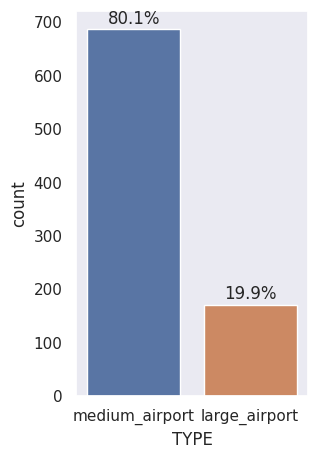

In [111]:
#Plot the counts of airport type
fig, ax = plt.subplots(figsize=(3, 5))
sns.countplot(x = 'TYPE', data=airports_us_med_large)
#Source code for labels: https://stackoverflow.com/questions/63603222/how-to-annotate-countplot-with-percentages-by-category
for p in ax.patches:
    percentage = f'{100 * p.get_height() / len(airports_us_med_large):.1f}%\n'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='center')
plt.show()

We can see that we have roughly 80% of our data marked as a medium airport. We'll have to see how this affects our recommendations or analysis if most of the roundtrips we recommend will fall between medium airports.

Since we know we'll need to join our airports data using the IATA Code, we'll drop the rows with missing values. We will also drop the continent column since they are no values and the ISO_Country column since have already filtered for the US and that is the only value present.

In [112]:
#Drop Continent and ISO Country
airports_us_med_large.drop(['CONTINENT', 'ISO_COUNTRY'], axis = 1, inplace = True)

#Drop rows with missing IATA Codes
airports_us_med_large.dropna(subset = 'IATA_CODE', inplace= True)

In [113]:
#Look at our data we will be using for analysis
data_shape(airports_us_med_large)
print('\n-------')
summary(airports_us_med_large)

Number of rows: 821
Number of columns: 6

-------


,Missing rows,Percent Missing Rows,Data Type,Min Value,Max Value,Number of Unique Values
TYPE,0,0.0%,object,large_airport,medium_airport,2
NAME,0,0.0%,object,Aberdeen Regional Airport,Zanesville Municipal Airport,821
ELEVATION_FT,0,0.0%,float64,-115.0,7820.0,630
MUNICIPALITY,0,0.0%,object,Aberdeen,Zanesville,693
IATA_CODE,0,0.0%,object,ABE,ZZV,821
COORDINATES,0,0.0%,object,"-100.2860031, 44.38270187","174.1139984, 52.71229935",821


<a id="1.1.1"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #0A800B; background-color: #ffffff;"><b>II. Tickets Data </b></h2>

In [114]:
#Sample a few rows of data
tickets_round_trip.sample(3)

,ITIN_ID,YEAR,QUARTER,ORIGIN,ORIGIN_COUNTRY,ORIGIN_STATE_ABR,ORIGIN_STATE_NM,ROUNDTRIP,REPORTING_CARRIER,PASSENGERS,ITIN_FARE,DESTINATION
602145,20191620622,2019,1,MCO,US,FL,Florida,1.0,AA,2.0,593.0,CLT
921564,201914176525,2019,1,SFO,US,CA,California,1.0,UA,39.0,297.0,LAX
661026,201912153816,2019,1,MSP,US,MN,Minnesota,1.0,DL,1.0,616.0,RNO


The variable we'll want to look at in this data will be the fare. We noted before that some fares were charged as 0 and there was a huge range between the min and max fares. Let's get a quick summary on some of the descriptive statistics for that column. We will also plot out the distributions of those values to decide if there's any outliers we should treat before analysis.

In [115]:
#Stats on fares column
tickets_round_trip['ITIN_FARE'].describe()

count    660585.000000
mean        472.945610
std         344.154653
min           0.000000
25%         279.000000
50%         415.000000
75%         595.000000
max       38400.000000
Name: ITIN_FARE, dtype: float64

Fare skewness is: 5.717930828466164


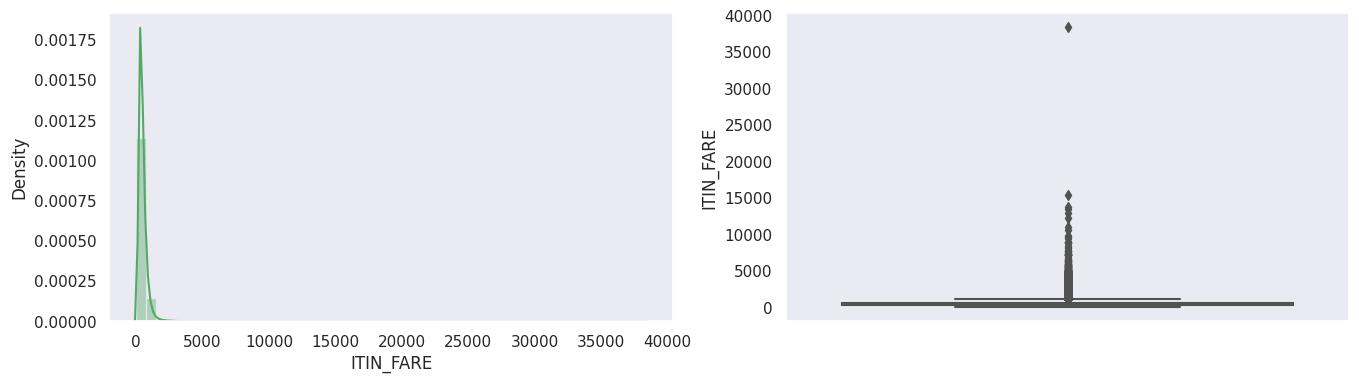

In [116]:
#Set figsize and flatten axes
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes_flat = axes.flatten()

#Dist and boxplots for the fare column
sns.distplot(tickets_round_trip['ITIN_FARE'], ax = axes_flat[0], kde = True, color = 'g')
sns.boxplot(y = 'ITIN_FARE', data = tickets_round_trip, ax = axes_flat[1], color = 'r')

#Print skewness of the data. Generally, higher values indicate heavy skewness.
print('Fare skewness is:', tickets_round_trip['ITIN_FARE'].skew())


Our suspicion is confirmed by the box and distribution plots. Our distribution is heavily right skewed with the presence of large fare amounts. This could be problematic when we're looking at the most profitable routes if we have 1-2 large fare prices skewing our results for certain airports. Let's define some ranges for outliers and see how much of our data is classified as an outlier.

In [117]:
#Create a function to calculate lower and upper ranges. We might need to perform the same check again in our flights data so a function serves us better
def lower_upper_range(df, col):
     
     #setup 25/75 percentile values and calculate IQR
     quant_25 = df[col].quantile(.25)
     quant_75 = df[col].quantile(.75)
     iqr = quant_75-quant_25

     #Calculate lower and upper bound thresholds for outliers
     l_range = quant_25 - 1.5*iqr
     up_range = quant_75 + 1.5*iqr

     return l_range, up_range

In [118]:
#Get lower and upper range values
lower_range, upper_range = lower_upper_range(tickets_round_trip, 'ITIN_FARE')

In [119]:
#Now that we have our ranges to classify outliers, we'll use this function to map the values as either outlier or not an outlier
def outliers(x):
    if x <= lower_range: return 'Outlier'
    elif x>= upper_range: return 'Outlier'
    else: return 'Not Outlier'

In [120]:
tickets_round_trip['Outlier'] = tickets_round_trip['ITIN_FARE'].apply(outliers)
tickets_round_trip.sample(3)

,ITIN_ID,YEAR,QUARTER,ORIGIN,ORIGIN_COUNTRY,ORIGIN_STATE_ABR,ORIGIN_STATE_NM,ROUNDTRIP,REPORTING_CARRIER,PASSENGERS,ITIN_FARE,DESTINATION,Outlier
598321,20191619509,2019,1,MCO,US,FL,Florida,1.0,AA,1.0,298.0,GPT,Not Outlier
533278,201913889251,2019,1,LAX,US,CA,California,1.0,UA,1.0,412.0,IAH,Not Outlier
958124,201912369182,2019,1,SLC,US,UT,Utah,1.0,DL,1.0,291.0,LAS,Not Outlier


In [121]:
#What percent of data is classified as an outlier?
tickets_round_trip['Outlier'].value_counts(normalize=True).multiply(100).round(2).astype(str) + '%'

Not Outlier    95.66%
Outlier         4.34%
Name: Outlier, dtype: object

With less than 5% of our data classified as an outlier, we can make a decision to drop the rows classified as an outlier. One thing to note is that the high fare prices are a naturally occurring part of the data that we're observing and it is possible to have extreme values for low/high fares. Our tickets data is sampled so we don't know what the distribution of values is for the original data.

Knowing this, we will choose to remove the outliers from the data to try to normalize the sample data we do have.  

In [122]:
#Subset for values not labeled as an outlier
tickets_round_trip = tickets_round_trip.query('Outlier == "Not Outlier"')

Fare skewness is: 0.37819262137008347


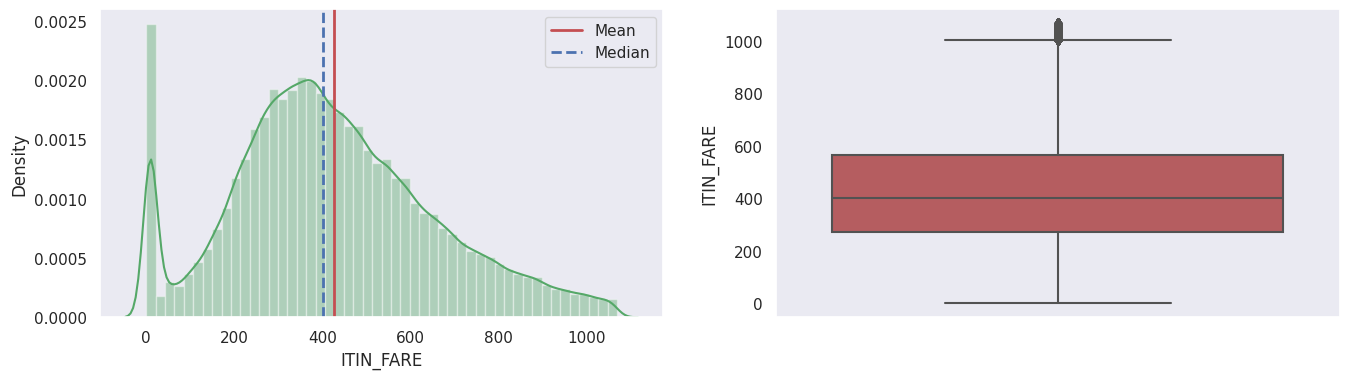

In [123]:
#Set figsize and flatten axes
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes_flat = axes.flatten()

#Dist and boxplots for the fare column
sns.distplot(tickets_round_trip['ITIN_FARE'], ax = axes_flat[0], kde = True, color = 'g')
sns.boxplot(y = 'ITIN_FARE', data = tickets_round_trip, ax = axes_flat[1], color = 'r')

#Calculate mean and median
mean_val = tickets_round_trip['ITIN_FARE'].mean()
median_val = tickets_round_trip['ITIN_FARE'].median()

#Plot vertical lines for mean and median
axes_flat[0].axvline(mean_val, color='r', linestyle='solid', linewidth=2, label='Mean')
axes_flat[0].axvline(median_val, color='b', linestyle='dashed', linewidth=2, label='Median')

#Legend for the mean/median lines
axes_flat[0].legend()

#Print skewness of the data. Generally, higher values indicate heavy skewness.
print('Fare skewness is:', tickets_round_trip['ITIN_FARE'].skew())

The distribution of our data is still slightly right skewed with a spike for fares charged as 0. Overall, the distribution of our fares is closer to the conditions we want for our data so we will accept these results.

In [124]:
#Decided to drop cols that won't aid in our analysis. 
cols_to_drop = ['YEAR','QUARTER','ORIGIN_COUNTRY','Outlier', 'ROUNDTRIP']
tickets_round_trip.drop(cols_to_drop, axis= 1, inplace= True)

#Drop rest of missing values
tickets_round_trip.dropna(inplace=True)

#Filter out for fares above 0
tickets_round_trip = tickets_round_trip.query('ITIN_FARE > 0')


In [125]:
#Look at our data we will be using for analysis
data_shape(tickets_round_trip)
print('\n-------')
summary(tickets_round_trip)

Number of rows: 625245
Number of columns: 8

-------


,Missing rows,Percent Missing Rows,Data Type,Min Value,Max Value,Number of Unique Values
ITIN_ID,0,0.0%,int64,2019119,201915258097,625137
ORIGIN,0,0.0%,object,ABE,YUM,407
ORIGIN_STATE_ABR,0,0.0%,object,AK,WY,52
ORIGIN_STATE_NM,0,0.0%,object,Alabama,Wyoming,52
REPORTING_CARRIER,0,0.0%,object,9E,YX,21
PASSENGERS,0,0.0%,float64,1.0,681.0,214
ITIN_FARE,0,0.0%,float64,1.0,1068.0,1068
DESTINATION,0,0.0%,object,ABE,YUM,390


<a id="1.1.1"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #0A800B; background-color: #ffffff;"><b>III. Flights Data </b></h2>

In [126]:
#Sample a few rows of data
flights_no_cancellations.sample(3)

,FL_DATE,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DESTINATION,DEST_CITY_NAME,DEP_DELAY,ARR_DELAY,CANCELLED,AIR_TIME,DISTANCE,OCCUPANCY_RATE
1164741,2019-02-01,OH,N709PS,5137,11057,CLT,"Charlotte, NC",11641,FAY,"Fayetteville, NC",-1.0,-6.0,0.0,25.0,118.0,0.64
12908,2019-03-25,WN,N433LV,2490,10800,BUR,"Burbank, CA",12889,LAS,"Las Vegas, NV",-5.0,-12.0,0.0,42.0,223.0,0.94
1270703,2019-02-22,UA,N33294,1610,11618,EWR,"Newark, NJ",13495,MSY,"New Orleans, LA",-7.0,-5.0,0.0,181.0,1167.0,0.99


Looking at our flights data, there's a few variables that we're interested in exploring further. For our analysis, we will be using the distance and delay columns to help us calculate the profit margins of airports. Let's first look at the distribution of these columns to help us make our decisions on any outliers and missing data for the distance and arrival delay columns.

We're going to create distribution and box plots for all of the columns we want to explore. We'll use a function to create these plots since we have multiple columns we want to perform the same operation on to help reduce redundancies in our code.

DEP_DELAY skewness is: 10.080908376154047
ARR_DELAY skewness is: 8.99434259459138
AIR_TIME skewness is: 1.6822493546944137
DISTANCE skewness is: 1.5702998388705525
OCCUPANCY_RATE skewness is: -0.0018688143040928203


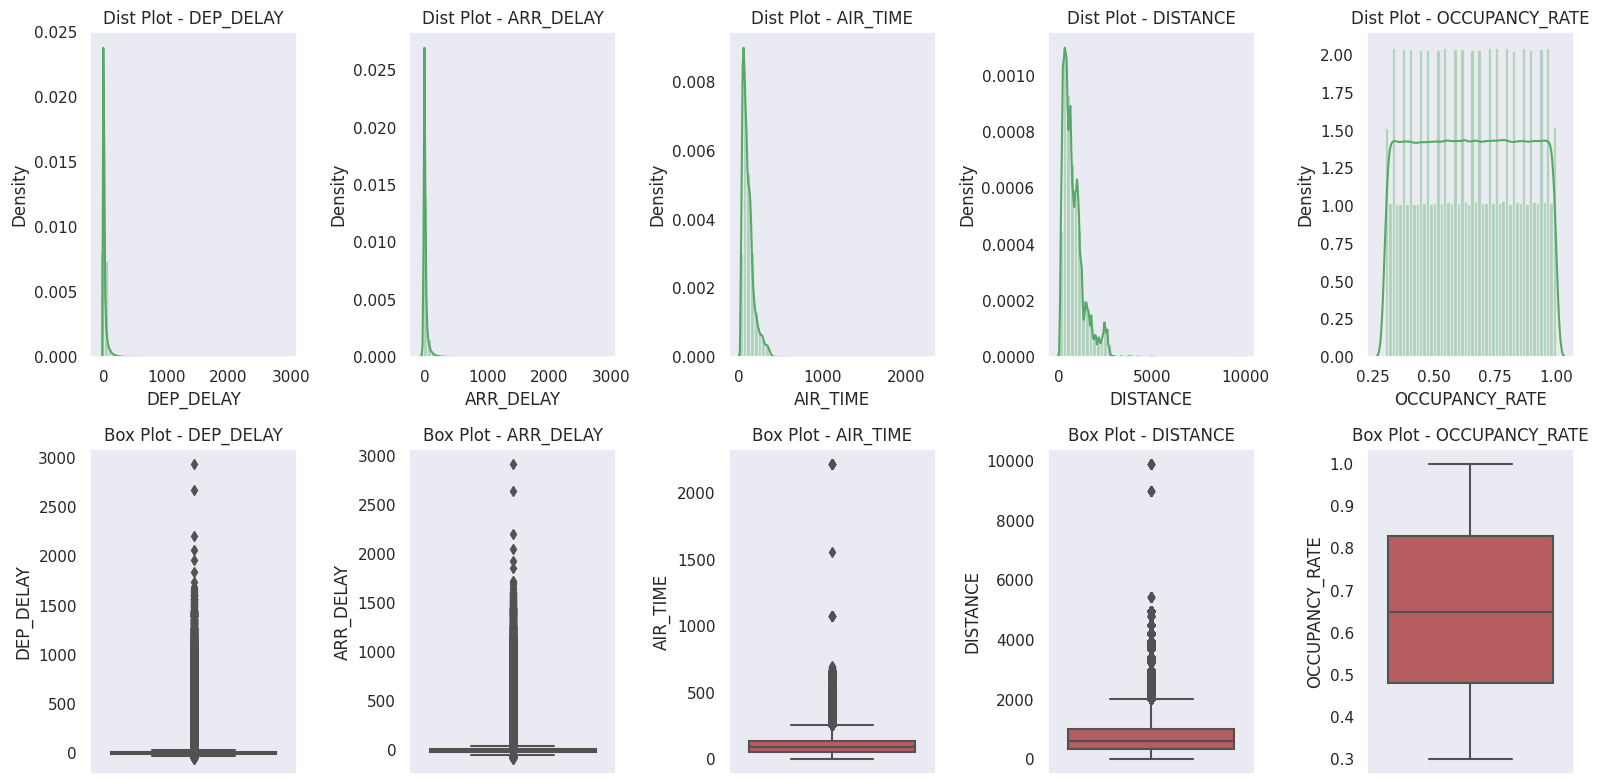

In [127]:
#Set up the 2 by 5 grid for subplots. The idea is to compare each variable's distribution and box plot together
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
axes_flat = axes.flatten()

#Create list of the columnss we're interested in
cols_to_plot = ['DEP_DELAY','ARR_DELAY','AIR_TIME','DISTANCE','OCCUPANCY_RATE']

#Plot distribution plots and box plots for the columns
for index, col in enumerate(flights_no_cancellations[cols_to_plot]):
    sns.distplot(flights_no_cancellations[col], ax=axes_flat[index], kde=True, color = 'g')
    sns.boxplot(y=flights_no_cancellations[col], ax=axes_flat[index+5], color = 'r')

    #Print skewness of the data. Generally, higher values indicate heavy skewness.
    print(col, 'skewness is:', flights_no_cancellations[col].skew())

    #Set titles for each subplot
    axes_flat[index].set_title(f'Dist Plot - {col}', fontsize=12)
    axes_flat[index+5].set_title(f'Box Plot - {col}', fontsize=12)

#Adjust layout and show the plot
plt.tight_layout()
plt.show()


<div style="border-radius:5px;border:#696B61 solid;padding: 14px; font-size:100%;text-align:left">

**Takeaway**:
1. All of the variables, outside of occupancy rate are right skewed, with the delay columns being heavily skewed based on their skewness output.  
2. Based on our skewness, we're going to focus on checking outliers from our delay columns. We'll perform the outlier check on distance to see if we find any value, but our focus will remain on the delay columns. We won't worry about air time since that is not a factor in the analysis we have to perform, we can choose to drop the missing values for that instead.
3. Depending on what we find with the outliers, if we choose to remove them, we could use mean/median values to fill in missing values if the distribution resembles a normal distribution.


Let's use our outlier functions to help us perform the same actions on the delay and distance columns.

In [128]:
#Create list of columns to treat for outliers
outlier_cols = ['DEP_DELAY', 'ARR_DELAY', 'DISTANCE']

#For loop to create the outlier columns for all of our variables
for col in outlier_cols:
    lower_range, upper_range = lower_upper_range(flights_no_cancellations, col)
    flights_no_cancellations[f'{col}_Outlier'] = flights_no_cancellations[col].apply(outliers)
    
flights_no_cancellations.sample(3)

,FL_DATE,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DESTINATION,DEST_CITY_NAME,DEP_DELAY,ARR_DELAY,CANCELLED,AIR_TIME,DISTANCE,OCCUPANCY_RATE,DEP_DELAY_Outlier,ARR_DELAY_Outlier,DISTANCE_Outlier
367736,2019-03-05,NK,N517NK,618,13495,MSY,"New Orleans, LA",13204,MCO,"Orlando, FL",0.0,6.0,0.0,77.0,551.0,0.39,Not Outlier,Not Outlier,Not Outlier
1230451,2019-02-02,AS,N546AS,38,14747,SEA,"Seattle, WA",11697,FLL,"Fort Lauderdale, FL",116.0,114.0,0.0,305.0,2717.0,0.47,Outlier,Outlier,Outlier
151582,2019-03-16,WN,N8603F,2609,15016,STL,"St. Louis, MO",10721,BOS,"Boston, MA",0.0,-28.0,0.0,117.0,1047.0,0.76,Not Outlier,Not Outlier,Not Outlier


In [129]:
#Print out the breakdown of outliers for each variable
outlier_check = ['DEP_DELAY_Outlier', 'ARR_DELAY_Outlier', 'DISTANCE_Outlier']
for col in outlier_check:
    print(col, ':')
    print('-----')
    print(flights_no_cancellations[col].value_counts(normalize=True).multiply(100).round(2).astype(str) + '%')
    print('\n')

DEP_DELAY_Outlier :
-----
Not Outlier    86.79%
Outlier        13.21%
Name: DEP_DELAY_Outlier, dtype: object


ARR_DELAY_Outlier :
-----
Not Outlier    90.62%
Outlier         9.38%
Name: ARR_DELAY_Outlier, dtype: object


DISTANCE_Outlier :
-----
Not Outlier    94.7%
Outlier         5.3%
Name: DISTANCE_Outlier, dtype: object




There are a significant amount of our rows classified as outliers based on our parameters for the upper and lower ranges for both of our delay columns. The distance column is relatively low compared to the delayed columns. 

Again, delays are a natural part of the process and data we are observing and occur randomly based on any given factors when traveling. Removing the outliers could have a huge impact on our overall analysis. Delays are unpredictable and there will be points in time that any airport will experience an abnormally large delay in both departure or arrival. With that being said, we will choose to remove these values to try to cater recommendations towards routes and airports that will experience a normal amount of variation in delays and not factor in any extreme values for delays.


In [130]:
#Create drop column as a True/False based on if any of our outlier columns have been marked as an Outlier
flights_no_cancellations['Drop_row'] = flights_no_cancellations[outlier_check].apply(lambda x: x=='Outlier').any(axis=1)
#Subset the data to exclude any rows marked True under the Drop_row column
flights_no_cancellations = flights_no_cancellations.query('Drop_row == False')

#Drop the outlier columns we created
flights_no_cancellations.drop(outlier_check, axis=1, inplace= True)
flights_no_cancellations.drop('Drop_row', axis=1, inplace=True)

After the outliers have been dropped, let's look at our distributions again for those 3 variables.

DEP_DELAY  skewness is: 1.320010409833452
ARR_DELAY  skewness is: 0.5106305241229666
DISTANCE  skewness is: 0.8742516117401216


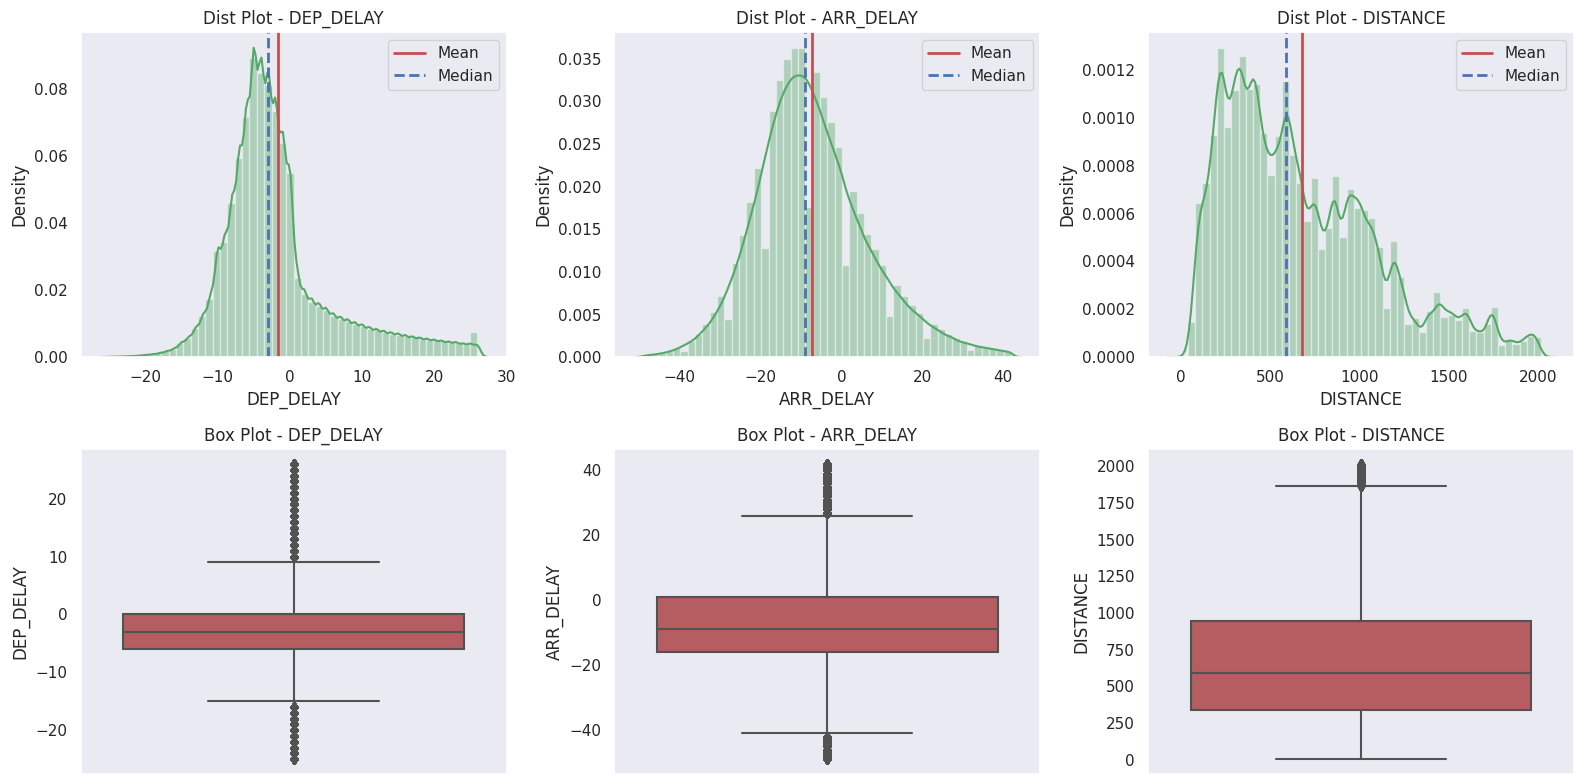

In [131]:
#Set up the 2 by 3 grid for subplots. The idea is to compare each variable's distribution and box plot together
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes_flat = axes.flatten()

#Create list of the columnss we're interested in
cols_to_plot = ['DEP_DELAY','ARR_DELAY','DISTANCE']

#Plot distribution plots and box plots for the columns
for index, col in enumerate(flights_no_cancellations[cols_to_plot]):
    sns.distplot(flights_no_cancellations[col], ax=axes_flat[index], kde=True, color = 'g')
    sns.boxplot(y=flights_no_cancellations[col], ax=axes_flat[index+3], color = 'r')

    #Print skewness of the data. Generally, higher values indicate heavy skewness.
    print(col, ' skewness is:', flights_no_cancellations[col].skew(skipna= True))

    #Set titles for each subplot
    axes_flat[index].set_title(f'Dist Plot - {col}', fontsize=12)
    axes_flat[index+3].set_title(f'Box Plot - {col}', fontsize=12)

    #Calculate mean and median
    mean_val = flights_no_cancellations[col].mean()
    median_val = flights_no_cancellations[col].median()

    #Plot vertical lines for mean and median
    axes_flat[index].axvline(mean_val, color='r', linestyle='solid', linewidth=2, label='Mean')
    axes_flat[index].axvline(median_val, color='b', linestyle='dashed', linewidth=2, label='Median')

    #Legend for the mean/median lines
    axes_flat[index].legend()

#Adjust layout and show the plot
plt.tight_layout()
plt.show()

has yielded the results we were hoping for. Since we now have a normal distribution for our arrival delays, we can fill the missing values for that column with the mean. For our distance, the distribution is still slightly skewed so filling the missing values with the median will be a more suitable replacement. 

Lastly, we will drop the few rows that don't have an occupancy rate since it's minuscule and we can't replace with a value based on the uniform distribution. We will also remove the missing airtime data.

As for data transformations, the date column has different formats so we will normalize that for our final dataset.

In [132]:
#Fill in missing values
flights_no_cancellations['ARR_DELAY'].fillna(flights_no_cancellations['ARR_DELAY'].mean(), inplace= True)
flights_no_cancellations['DISTANCE'].fillna(flights_no_cancellations['DISTANCE'].median(), inplace=True)

#Drop rows missing occupancy rate
flights_no_cancellations.dropna(subset=['OCCUPANCY_RATE','AIR_TIME'], inplace= True)

In [133]:
#Transform FL_Date into a date column. Replace / with - to make format consistent first.
flights_no_cancellations['FL_DATE'] = flights_no_cancellations['FL_DATE'].replace('/','-')
flights_no_cancellations['FL_DATE'] = pd.to_datetime(flights_no_cancellations['FL_DATE']).dt.strftime('%Y-%m-%d')

In [134]:
#Look at our data we will be using for analysis
data_shape(flights_no_cancellations)
print('\n-------')
summary(flights_no_cancellations)

Number of rows: 1512097
Number of columns: 16

-------


,Missing rows,Percent Missing Rows,Data Type,Min Value,Max Value,Number of Unique Values
FL_DATE,0,0.0%,object,2019-01-01,2019-03-31,90
OP_CARRIER,0,0.0%,object,9E,ZW,26
TAIL_NUM,0,0.0%,object,215NV,N999JQ,5901
OP_CARRIER_FL_NUM,0,0.0%,object,NaN,NaN,8812
ORIGIN_AIRPORT_ID,0,0.0%,int64,10135,16218,360
ORIGIN,0,0.0%,object,ABE,YUM,360
ORIGIN_CITY_NAME,0,0.0%,object,"Aberdeen, SD","Yuma, AZ",354
DEST_AIRPORT_ID,0,0.0%,int64,10135,16218,360
DESTINATION,0,0.0%,object,ABE,YUM,360
DEST_CITY_NAME,0,0.0%,object,"Aberdeen, SD","Yuma, AZ",354


<a id="2"></a>
# <div style="padding:20px;color:white;margin:0;font-size:35px;font-family:Verdana;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b>C. Analysis</b></div>

Now that we have all our data ready for analysis, we will start with merging the datasets appropriately to extract the information we will need.

<div style="padding: 14px;font-size:100%;text-align:left">
Metadata Created:

|Item | Field Name | Description |
|:---| :--- |:--- |
| 1 | round_trip_route	| Identifier for the full route |
| 2 | avg_fare	| Average fare for the specified round trip route and carrier |
| 3 | distance_costs |	Costs associated with the miles traveled on the flight |
| 4| op_costs |	Costs associated with the airport type. This is total cost for using both airports for the trip|
| 5 | arr_delay_cost |	Costs associated with arrival delays |
| 6 | dep_delay_cost |	Costs associated with departure delays |
| 7 | total_cost |	Total Cost for the flight |
| 8 | passenger_fare|	Total Fare for all passengers on the flight|
| 9 | bag_revenue |	Total revenue charged for bags checked in for the flight |
| 10 | total_revenue |	Total revenue for the flight |
| 11 | total_profit| Total profit for the flight|
| 12 | arr_delay_cost_ontime|	Checks whether a flight was delayed during arrival (1 = on time, 0 = delayed) |
| 13 | dep_delay_cost_ontime|	Checks whether a flight was delayed during departure (1 = on time, 0 = delayed) |

<a id="1.1.1"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #0A800B; background-color: #ffffff;"><b>1. Data Munging </b></h2>

Since we'll be merging datasets throughout, we'll create a function to help us achieve that without repeating syntax or making it confusing to follow.

In [135]:
#Function to merge datasets
def merge_dfs(df1, df2, left, right, suffix = (), how = 'inner'):
    merged_df = df1.merge(df2, left_on = left, right_on = right,how = how, suffixes = suffix)
    return merged_df

First we'll subset the airports data to pull the type, IATA Code, municipality, and the coordinates. These are the columns we'll be using for analysis so we'll leave the rest of the columns out.

In [136]:
#Subset the desired columns from out airports data
airports_type_coordinates = airports_us_med_large[['TYPE', 'IATA_CODE','COORDINATES', 'MUNICIPALITY']]
airports_type_coordinates.sample(3)

,TYPE,IATA_CODE,COORDINATES,MUNICIPALITY
38468,large_airport,FAI,"-147.8560028, 64.81510162",Fairbanks
27815,large_airport,JFK,"-73.77890015, 40.63980103",New York
30140,large_airport,SPS,"-98.491898, 33.9888",Wichita Falls


Let's start with merging the airports and flights data first. We'll need to perform two merges with this data. The first one will be merging to the origin airport using the origin and IATA codes so we can pull in the respective airport type and coordinates for the origin. The second merge we will use the destination and IATA code so we can the respective airport type and coordinates for the destination.

We perform the merge twice because we need to know the airport type for both the origin and destination to calculate the fixed costs associated with the type of airport. The method of the merge will be an inner join because we only want the information for the airports that are in common between the two datasets since the airport data contains more airports.

In [137]:
#Set the merge conditions
left = 'ORIGIN'
right = 'IATA_CODE'

#Merge into new dataframe using out function. Our default condition is an inner join and optional suffixes
airport_flight = merge_dfs(flights_no_cancellations, airports_type_coordinates, left, right)

airport_flight.sample(3)

,FL_DATE,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DESTINATION,DEST_CITY_NAME,DEP_DELAY,ARR_DELAY,CANCELLED,AIR_TIME,DISTANCE,OCCUPANCY_RATE,TYPE,IATA_CODE,COORDINATES,MUNICIPALITY
1254417,2019-01-05,OO,N278SY,3984,12266,IAH,"Houston, TX",12953,LGA,"New York, NY",-2.0,-25.0,0.0,179.0,1416.0,0.65,large_airport,IAH,"-95.34140014648438, 29.984399795532227",Houston
982913,2019-03-27,QX,N439QX,2169,14057,PDX,"Portland, OR",14747,SEA,"Seattle, WA",-3.0,3.0,0.0,27.0,129.0,0.67,large_airport,PDX,"-122.5979996, 45.58869934",Portland
12931,2019-03-13,WN,N727SW,2272,14679,SAN,"San Diego, CA",14683,SAT,"San Antonio, TX",-1.0,-29.0,0.0,120.0,1129.0,0.87,large_airport,SAN,"-117.190002441, 32.7336006165",San Diego


In [138]:
#Set the merge conditions. This time we will set suffixes since IATA code and cooridnates will be repeated.
left = 'DESTINATION'
right = 'IATA_CODE'
suffix = ('_Origin', '_Destination')

#Merge into new dataframe using out function. Our default condition is an inner join and we have a suffix condition this time. 
airport_flight = merge_dfs(airport_flight, airports_type_coordinates,left, right ,suffix)
airport_flight.sample(3)

,FL_DATE,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DESTINATION,DEST_CITY_NAME,...,DISTANCE,OCCUPANCY_RATE,TYPE_Origin,IATA_CODE_Origin,COORDINATES_Origin,MUNICIPALITY_Origin,TYPE_Destination,IATA_CODE_Destination,COORDINATES_Destination,MUNICIPALITY_Destination
907501,2019-01-28,WN,N405WN,1518,14869,SLC,"Salt Lake City, UT",12889,LAS,"Las Vegas, NV",...,368.0,0.50,large_airport,SLC,"-111.97799682617188, 40.78839874267578",Salt Lake City,large_airport,LAS,"-115.1520004, 36.08010101",Las Vegas
1221389,2019-01-29,MQ,N667GB,3375,13303,MIA,"Miami, FL",14685,SAV,"Savannah, GA",...,440.0,0.80,large_airport,MIA,"-80.29060363769531, 25.79319953918457",Miami,large_airport,SAV,"-81.20210266, 32.12760162",Savannah
725890,2019-03-24,UA,N18220,723,11618,EWR,"Newark, NJ",11057,CLT,"Charlotte, NC",...,529.0,0.61,large_airport,EWR,"-74.168701171875, 40.692501068115234",Newark,large_airport,CLT,"-80.94309997558594, 35.2140007019043",Charlotte


Our airports and flights data have merged correctly as we now have an airport type for all of our origins and destinations. We can now merge this the tickets data. Before we do that, let's create a column to output the roundtrip route for both the merged data and the tickets data. We can use this full route to merge the data into a datasets containing all of our data.

In [139]:
#Create new column with the full route combination
airport_flight['round_trip_route'] = airport_flight['ORIGIN']+'-'+airport_flight['DESTINATION']

#Modify the column to sort the combination with the code that occurs first alphabetically. We do this because we want the combined route to display one value for both combinations of the route
#For example, LAX-SFO and SFO-LAX will now both show as LAX-SFO. This way we can group by the routes no matter which origin they have. 
airport_flight['round_trip_route'] = airport_flight['round_trip_route'].apply(lambda x: '-'.join(sorted(x.split('-'))))
airport_flight.sample(3)

,FL_DATE,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DESTINATION,DEST_CITY_NAME,...,OCCUPANCY_RATE,TYPE_Origin,IATA_CODE_Origin,COORDINATES_Origin,MUNICIPALITY_Origin,TYPE_Destination,IATA_CODE_Destination,COORDINATES_Destination,MUNICIPALITY_Destination,round_trip_route
784922,2019-01-28,YV,N926LR,5754,11540,ELP,"El Paso, TX",14107,PHX,"Phoenix, AZ",...,0.59,medium_airport,ELP,"-106.3779984, 31.80719948",El Paso,large_airport,PHX,"-112.01200103759766, 33.43429946899414",Phoenix,ELP-PHX
632587,2019-03-12,9E,N301PQ,5415,11042,CLE,"Cleveland, OH",12953,LGA,"New York, NY",...,0.38,large_airport,CLE,"-81.8498001099, 41.4117012024",Cleveland,large_airport,LGA,"-73.87259674, 40.77719879",New York,CLE-LGA
1361762,2019-01-10,ZW,N410AW,4871,13930,ORD,"Chicago, IL",10980,CHA,"Chattanooga, TN",...,0.93,large_airport,ORD,"-87.9048, 41.9786",Chicago,large_airport,CHA,"-85.20379638671875, 35.035301208496094",Chattanooga,CHA-ORD


In [140]:
#Perform the same operation on the tickets data
tickets_round_trip['round_trip_route'] = tickets_round_trip['ORIGIN']+'-'+tickets_round_trip['DESTINATION']
tickets_round_trip['round_trip_route'] = tickets_round_trip['round_trip_route'].apply(lambda x: '-'.join(sorted(x.split('-'))))
tickets_round_trip.sample(3)


,ITIN_ID,ORIGIN,ORIGIN_STATE_ABR,ORIGIN_STATE_NM,REPORTING_CARRIER,PASSENGERS,ITIN_FARE,DESTINATION,round_trip_route
418912,201912686816,HNL,HI,Hawaii,HA,26.0,219.0,KOA,HNL-KOA
1080374,20191621375,MCO,FL,Florida,AA,1.0,628.0,ORF,MCO-ORF
81054,201911561684,ATL,GA,Georgia,DL,1.0,915.0,DEN,ATL-DEN


Now we can use the round trip route to merge the tickets data with our merged airports and flights data. Before we do that, we need to get the tickets data into the right shape. We have samples of the itineraries containing passenger and fare information. If we try to join this as it is, our data will expand in terms of rows because we will be trying to join every occurrence of a flight path from the airports/flights data to the tickets data.

We want to merge what the average fare would be for the round trip route and the carrier. We will be using the occupancy rate for the flight to determine passengers so all we would need is what the average per person fare would be for that particular route and carrier based on the sample data we have.


In [141]:
#Group the tickets based on the route and the carrier and find the average fare
tickets_grouped = tickets_round_trip.groupby(['round_trip_route', 'REPORTING_CARRIER'])['ITIN_FARE'].mean().round(2).to_frame('avg_fare').reset_index()
tickets_grouped.sort_values('avg_fare', ascending= False)

,round_trip_route,REPORTING_CARRIER,avg_fare
12134,BNA-PUW,DL,1068.0
58574,OGG-SYR,OO,1068.0
24747,CRW-HNL,UA,1068.0
30111,DLG-MFR,QX,1068.0
84,ABE-ELP,DL,1068.0
...,...,...,...
51062,LGA-LRD,MQ,10.0
41681,GUC-JFK,AA,10.0
54657,MFE-SAF,MQ,7.0
1899,ADQ-ENA,AS,5.0


Now we have the tickets data in the format we want. We can now join the existing routes in both data sets and pull in the average fare for that particular route and operating carrier.

In [142]:
#Set the merge conditions.
left = ['round_trip_route', 'OP_CARRIER']
right = ['round_trip_route', 'REPORTING_CARRIER']

#Merge into new dataframe using out function. Our default condition is an inner join. 
full_df = merge_dfs(airport_flight, tickets_grouped,left, right)
full_df.sample(3)

,FL_DATE,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DESTINATION,DEST_CITY_NAME,...,IATA_CODE_Origin,COORDINATES_Origin,MUNICIPALITY_Origin,TYPE_Destination,IATA_CODE_Destination,COORDINATES_Destination,MUNICIPALITY_Destination,round_trip_route,REPORTING_CARRIER,avg_fare
120032,2019-03-05,WN,N7719A,1107,15016,STL,"St. Louis, MO",13232,MDW,"Chicago, IL",...,STL,"-90.370003, 38.748697",St Louis,large_airport,MDW,"-87.752403, 41.785999",Chicago,MDW-STL,WN,400.40
515545,2019-03-12,B6,N529JB,2236,13487,MSP,"Minneapolis, MN",10721,BOS,"Boston, MA",...,MSP,"-93.221802, 44.882",Minneapolis,large_airport,BOS,"-71.00520325, 42.36429977",Boston,BOS-MSP,B6,272.25
357467,2019-01-24,WN,N952WN,681,10529,BDL,"Hartford, CT",10821,BWI,"Baltimore, MD",...,BDL,"-72.68319702149999, 41.9388999939",Hartford,large_airport,BWI,"-76.668297, 39.1754",Baltimore,BDL-BWI,WN,334.68


Great, now we have all our data into one dataset and have confirmed the columns we expected to have after our merges.

<a id="1.1.1"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #0A800B; background-color: #ffffff;"><b>2. Top 10 Busiest Round Trips </b></h2>

To calculate the busiest round trips, we can group by the round trip route and count the amount of times the route shows up in the dataset. We'll use origin to count since we have no null values, but any column could work. Once grouped, we will create a rank column to filter on in case we add in more data and always want to show the top 10.

In [143]:
#Group by the round trip route, and count the occurences of flights
top_busiest = full_df.groupby('round_trip_route')['ORIGIN'].count().to_frame('Number of Trips').reset_index().sort_values('Number of Trips', ascending=False)

#Create a rank column based on the number of trips. We'll use the dense method in case there are ever any ties and we won't want to skip the ranks.
#If we want only 10 airports regardless of ties, we can change it to the default rank method
top_busiest['Rank'] = top_busiest['Number of Trips'].rank(method='dense', ascending= False)

In [144]:
#Query for only top 10
top_10_busiest = top_busiest.query('Rank < 11')
top_10_busiest

,round_trip_route,Number of Trips,Rank
1930,LAX-SFO,6428,1.0
1850,LAS-LAX,5538,2.0
1968,LGA-ORD,5408,3.0
1612,HNL-OGG,4648,4.0
1929,LAX-SEA,4362,5.0
176,ATL-MCO,4276,6.0
2337,PDX-SEA,4202,7.0
144,ATL-FLL,4081,8.0
172,ATL-LGA,3867,9.0
512,BOS-LGA,3753,10.0


<a id="1.1.1"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #0A800B; background-color: #ffffff;"><b>3. Top 10 most profitable routes </b></h2>

<div style="border-radius:10px;border:#0C6A86 solid;padding: 14px; font-size:100%;text-align:left">

For the most profitable routes, there's a few values we have to calculate first. In general, our profit formula will be as follows:

***Profit = Revenue - Cost***

So, we need to calculate the total revenue and costs for all of the flights. Once we have that, we can aggregate the information to the round trip route.

We know there is a fixed cost for the type of airport on both parts of the round trip route. The function will add the type columns for both the airport and destination. We assign values based on what the combination between the two airports is. 

Ex:
1. Medium-Medium = 5000*2 = 10000
2. Large-Large = 10000*2 = 20000
3. If it's not the above combination, we know it's a mixed combination and can add the costs for both types to be 15000

In [145]:
#Function for fixed operational costs
def operational_costs(df):
    if df['TYPE_Origin'] + df['TYPE_Destination'] == "medium_airport"*2: return 10000
    elif df['TYPE_Origin'] + df['TYPE_Destination'] == "large_airport"*2: return 20000
    else: return 15000

In [146]:
#Create variables for the travel costs associated per mile and the passengers as a result of occupancy. We will also create a variable for the cost of an airplane to use in our BE analysis.
travel_costs = 9+1.18
passengers = full_df['OCCUPANCY_RATE']*200
airplane = 90000000

In [147]:
#Create columns for all of the costs

#Costs associated with the miles traveled
full_df['distance_costs'] = full_df['DISTANCE']*travel_costs

#Fixed operational costs
full_df['op_costs'] = full_df.apply(operational_costs, axis = 1)

#Costs associated with delays. If any delay is below 0 (including early departures/arrivals) we will associate the cost as 0. If above, add $75 for each minute above.
full_df['arr_delay_cost'] = full_df['ARR_DELAY'].apply(lambda x: 0 if x<=15 else 75*(x-15))
full_df['dep_delay_cost'] = full_df['DEP_DELAY'].apply(lambda x: 0 if x<=15 else 75*(x-15))

#Add up all of the costs
full_df['total_cost'] = full_df['distance_costs']+full_df['op_costs']+full_df['arr_delay_cost']+full_df['dep_delay_cost']

In [148]:
#Create columns for all of the revenue

#Revenue from passengers
full_df['passenger_fare'] = full_df['avg_fare']*passengers

#Revenue from bags. We know half the passengers will check in a bag and pay $70 for the whole trip
full_df['bag_revenue'] = passengers*.5*70

#Add up all of the revenue
full_df['total_revenue'] = full_df['passenger_fare']+full_df['bag_revenue']

In [149]:
#Calculate total profit for each round trip
full_df['total_profit']=full_df['total_revenue']-full_df['total_cost']

In [150]:
#Group by the round trip route, and sum the total revenue, costs, and profits
top_profitable = full_df.groupby('round_trip_route')[['total_revenue','total_cost','total_profit']].sum().reset_index().sort_values('total_profit', ascending=False)

#Merge the existing data on the number of flights we have so we can see the number of flights as well
top_profitable_flights = merge_dfs(top_profitable, top_busiest, 'round_trip_route', 'round_trip_route')

#Modify the rank column to rank based on profit.
top_profitable_flights['Rank'] = top_profitable_flights['total_profit'].rank(method = 'dense', ascending= False)

In [151]:
#Query for only top 10
top_10_profitable = top_profitable_flights.query('Rank < 11')
top_10_profitable

,round_trip_route,total_revenue,total_cost,total_profit,Number of Trips,Rank
0,DCA-ORD,2.244192e+08,8.243600e+07,1.419832e+08,3135,1.0
1,ATL-CLT,1.888263e+08,6.289436e+07,1.259319e+08,2814,2.0
2,LGA-ORD,2.687783e+08,1.491726e+08,1.196057e+08,5408,3.0
3,DCA-LGA,1.763786e+08,5.961847e+07,1.167602e+08,2675,4.0
4,LAX-SFO,2.672517e+08,1.512788e+08,1.159729e+08,6428,5.0
5,ATL-DCA,1.956935e+08,8.078536e+07,1.149081e+08,3152,6.0
6,ATL-MCO,2.181685e+08,1.033236e+08,1.148450e+08,4276,7.0
7,ATL-LGA,2.192201e+08,1.076457e+08,1.115744e+08,3867,8.0
8,HNL-OGG,1.853814e+08,7.463241e+07,1.107490e+08,4648,9.0
9,CLT-GSP,1.374526e+08,2.923129e+07,1.082213e+08,1405,10.0


Now that we have an idea of the most profitable and busiest routes, we'll start developing some visuals to help us recommend the 5 routes to the airline company. 

First, let's create two new fields to track whether or not the flight was delayed due to an arrival or departure. We will use this column to help aid in our visualizations.

In [152]:
#Create a list for the cols we want to use to track this.
delay_cols = ['arr_delay_cost', 'dep_delay_cost']

#We'll mark a 1 or 0 depending on our delay costs to track if there was a delay or not. Once we have these columns, we can use them as a counter to track on time percentage
for col in delay_cols:
    full_df[f'{col}_ontime'] = full_df[col].apply(lambda x: 1 if x == 0 else 0)
    
full_df.sample(3)

,FL_DATE,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DESTINATION,DEST_CITY_NAME,...,op_costs,arr_delay_cost,dep_delay_cost,total_cost,passenger_fare,bag_revenue,total_revenue,total_profit,arr_delay_cost_ontime,dep_delay_cost_ontime
557061,2019-01-27,B6,N705JB,119,10257,ALB,"Albany, NY",13204,MCO,"Orlando, FL",...,15000,0.0,0.0,25923.14,50028.90,3990.0,54018.90,28095.76,1,1
204014,2019-03-25,WN,N725SW,1753,13851,OKC,"Oklahoma City, OK",15016,STL,"St. Louis, MO",...,20000,0.0,0.0,24703.16,72616.26,6510.0,79126.26,54423.10,1,1
323799,2019-02-11,DL,N366NW,2393,10397,ATL,"Atlanta, GA",11298,DFW,"Dallas/Fort Worth, TX",...,20000,0.0,0.0,27441.58,86007.30,6650.0,92657.30,65215.72,1,1


In [153]:
#Test to see our output matches expectations. Create two data frames, one with the on time sum and one with total flight counts
delays = full_df.groupby('ORIGIN')[['arr_delay_cost_ontime', 'dep_delay_cost_ontime']].sum().reset_index()
total_flights = full_df.groupby('ORIGIN')['DESTINATION'].count().to_frame('Total Flights').reset_index()

#Concat dfs together
on_time_tracker = pd.concat((delays, total_flights), axis = 1)
on_time_tracker

,ORIGIN,arr_delay_cost_ontime,dep_delay_cost_ontime,ORIGIN,Total Flights
0,ABE,823,866,ABE,902
1,ABI,382,410,ABI,435
2,ABQ,4833,4833,ABQ,5084
3,ABR,134,140,ABR,142
4,ABY,218,213,ABY,224
...,...,...,...,...,...
320,WRG,137,140,WRG,141
321,XNA,2628,2736,XNA,2853
322,YAK,90,90,YAK,98
323,YKM,229,231,YKM,255


To get our on-time percentage we would just need to divide the arrival and delay counts by the total flights. We won't do that here so we can easily perform that in the visualization portion. Let's export our dataset to use for visualizations.

In [154]:
#Export to CSV
full_df.to_csv('full_data.csv', index = False)

<a id="1.1.1"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #0A800B; background-color: #ffffff;"><b>4. Recommendations </b></h2>

<div style="border-radius:10px;border:#0C6A86 solid;padding: 14px; font-size:100%;text-align:left">

Recommended Round Trip Routes:


|Route | 
|:---| 
| ATL-CLT | 
| CLT-GSP | 
| DCA-ORD |
| HNL-OGG | 
| LAX-SFO | 

Factors of Recommendations:

Our recommendations for the routes are based on the following factors:

1. The route falls within the most overall profitable routes

2. Routes that operate above the average profit per trip when compared across the top 10 profitable routes

3. For routes that operate below the average profit per trip, we took into consideration the number of competitors operating at that airport and the amount of flights for that route

4. Lastly, we understand the competitive advantage for the company is to be on time, so we also preferred airports that had a high percentage of on time departure and arrival

**On time was defined as anything below 15 minutes when compared to flight times and did not incur any extra costs, including early departures and arrivals.** 

The link for the viz below: https://public.tableau.com/views/DataChallenge_16910971085260/RecommendedRoutesDashboard?:language=en-US&:display_count=n&:origin=viz_share_link

In [155]:
%%html
<div class='tableauPlaceholder' id='viz1691116791488' style='position: relative'><noscript><a href='#'><img alt='Recommended Routes Dashboard ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Da&#47;DataChallenge_16910971085260&#47;RecommendedRoutesDashboard&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='DataChallenge_16910971085260&#47;RecommendedRoutesDashboard' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Da&#47;DataChallenge_16910971085260&#47;RecommendedRoutesDashboard&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1691116791488');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='1366px';vizElement.style.height='1027px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='1366px';vizElement.style.height='1027px';} else { vizElement.style.width='100%';vizElement.style.height='2627px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

<a id="1.1.1"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #0A800B; background-color: #ffffff;"><b>5. Break Even Analysis </b></h2>

We'll perform a breakeven analysis on the 5 routes we recommend. We will calculate how many flights it would take to breakeven on the cost of the airplane.

Airplane Cost = (Revenue - Fixed Cost + Variable Cost = Profit per Trip)

Num of flights required for BE = Airplane Cost/Profit per trip

In [156]:
#List of recommended routes
routes = ['ATL-CLT', 'CLT-GSP', 'DCA-ORD', 'HNL-OGG', 'LAX-SFO']

#subset for data just on our recommended routes
be_analysis = full_df[full_df['round_trip_route'].isin(routes)]
len(be_analysis)

18430

In [157]:
#Get average revenue, cost, and profit for each roundtrip route
be_analysis = be_analysis.groupby('round_trip_route')[['total_revenue','total_cost', 'total_profit']].mean().reset_index().round(2)

#Create new column for flights required to breakeven by dividing the airplane cost by the average profit for the route
be_analysis['Number of Flights Required'] = (airplane/be_analysis['total_profit']).round(1)
be_analysis.sort_values('Number of Flights Required')

,round_trip_route,total_revenue,total_cost,total_profit,Number of Flights Required
1,CLT-GSP,97831.03,20805.19,77025.84,1168.4
2,DCA-ORD,71585.06,26295.38,45289.68,1987.2
0,ATL-CLT,67102.44,22350.52,44751.92,2011.1
3,HNL-OGG,39884.13,16056.89,23827.25,3777.2
4,LAX-SFO,41576.19,23534.35,18041.84,4988.4


<a id="1.1.1"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #0A800B; background-color: #ffffff;"><b>6. KPI Recommendations  </b></h2>

<div style="border-radius:10px;border:#0C6A86 solid;padding: 14px; font-size:100%;text-align:left">

KPIs to consider:

1. On-Time Percentage: Track on time percentage flights for both airport legs of the route
2. Average revenue for the routes
3. Occupancy Rates for flights
4. Customer Satisfaction (optional survey based)
5. Reasons for Delay
6. Cancelled flight percentage

<a id="1.1.1"></a>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #0A800B; background-color: #ffffff;"><b>7. Next Steps  </b></h2>

<div style="border-radius:10px;border:#0C6A86 solid;padding: 14px; font-size:100%;text-align:left">

Things to consider:

1. Compare how the routes change if we did not exclude the outliers we found
2. Consider seasonal effects on prices and overall impact on the recommended routes
3. Gather weather information to see if the large delays were due to external conditions or internal to the airline
4. Gather more data (beyond 1 quarter)
5. Explore ticket and flight information for one-way offerings